# LHCb Magnetic Field Analysis
## Characterising the `twodip.rtf` Field Map

**Goal**: Understand the LHCb dipole magnetic field boundaries, structure and behaviour to inform training data generation for the track extrapolation neural network.

**Field map**: `twodip.rtf` — 81×81×146 regular grid, 100mm spacing, covering the full LHCb dipole region.

**Key questions**:
1. What are the spatial boundaries of the field?
2. Where is the field significant (active region)?
3. How do Bx, By, Bz vary with position?
4. What z-range should we use for training data?
5. How good is the Gaussian approximation?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from scipy.optimize import curve_fit
import sys

# Add utils to path
sys.path.insert(0, str(Path('.').resolve().parent / 'utils'))
from magnetic_field import InterpolatedFieldNumpy, GaussianFieldNumpy, GaussianFieldParams, C_LIGHT

# Field map path
FIELD_MAP_PATH = Path('.').resolve().parent.parent.parent / 'field_maps' / 'twodip.rtf'
print(f"Field map: {FIELD_MAP_PATH}")
print(f"Exists: {FIELD_MAP_PATH.exists()}")

# Plot styling
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## 1. Load Raw Field Map Data

Load the `twodip.rtf` file and inspect the grid structure, coordinate ranges, and field component ranges.

In [ ]:
# Load raw field map
data = np.loadtxt(FIELD_MAP_PATH)
print(f"Data shape: {data.shape}")
print(f"Columns: x, y, z, Bx, By, Bz")

# Extract coordinates and field components
x_raw, y_raw, z_raw = data[:, 0], data[:, 1], data[:, 2]
Bx_raw, By_raw, Bz_raw = data[:, 3], data[:, 4], data[:, 5]

# Get unique grid coordinates
x_grid = np.sort(np.unique(x_raw))
y_grid = np.sort(np.unique(y_raw))
z_grid = np.sort(np.unique(z_raw))
nx, ny, nz = len(x_grid), len(y_grid), len(z_grid)

print(f"\nGrid dimensions: {nx} × {ny} × {nz} = {nx*ny*nz} points")
print(f"Grid spacing: dx={x_grid[1]-x_grid[0]:.0f}mm, dy={y_grid[1]-y_grid[0]:.0f}mm, dz={z_grid[1]-z_grid[0]:.0f}mm")
print(f"\nCoordinate ranges:")
print(f"  x: [{x_grid[0]:.0f}, {x_grid[-1]:.0f}] mm")
print(f"  y: [{y_grid[0]:.0f}, {y_grid[-1]:.0f}] mm")
print(f"  z: [{z_grid[0]:.0f}, {z_grid[-1]:.0f}] mm")
print(f"\nField component ranges (raw):")
print(f"  Bx: [{Bx_raw.min():.4f}, {Bx_raw.max():.4f}]")
print(f"  By: [{By_raw.min():.4f}, {By_raw.max():.4f}]")
print(f"  Bz: [{Bz_raw.min():.4f}, {Bz_raw.max():.4f}]")

# Reshape: data ordering is z(slowest) -> x -> y(fastest)
Bx_3d = Bx_raw.reshape(nz, nx, ny).transpose(1, 2, 0)  # [nx, ny, nz]
By_3d = By_raw.reshape(nz, nx, ny).transpose(1, 2, 0)
Bz_3d = Bz_raw.reshape(nz, nx, ny).transpose(1, 2, 0)

# Find center indices
ix0 = np.searchsorted(x_grid, 0)
iy0 = np.searchsorted(y_grid, 0)
print(f"\nCenter indices: ix0={ix0}, iy0={iy0}")
print(f"  x[{ix0}] = {x_grid[ix0]:.0f} mm, y[{iy0}] = {y_grid[iy0]:.0f} mm")

Data shape: (957906, 6)
Columns: x, y, z, Bx, By, Bz

Grid dimensions: 81 × 81 × 146 = 957906 points
Grid spacing: dx=100mm, dy=100mm, dz=100mm

Coordinate ranges:
  x: [-4000, 4000] mm
  y: [-4000, 4000] mm
  z: [-500, 14000] mm

Field component ranges (raw):
  Bx: [-8756.8091, 8756.8091]
  By: [-33024.0670, 16511.9355]
  Bz: [-8756.8091, 8756.8091]

Center indices: ix0=40, iy0=40
  x[40] = 0 mm, y[40] = 0 mm


## 2. By(z) Profile at the Origin

The dominant field component is By (vertical, bending tracks in the x-z plane). Plot By along the beam axis to find the peak location, width, and effective field region.

Peak By = -1.0320 T at z = 5000 mm
FWHM: 4000 mm (z = 3000 to 7000 mm)

Active region (|B| > 0.01 T): z = -300 to 14000 mm
Active width: 14300 mm


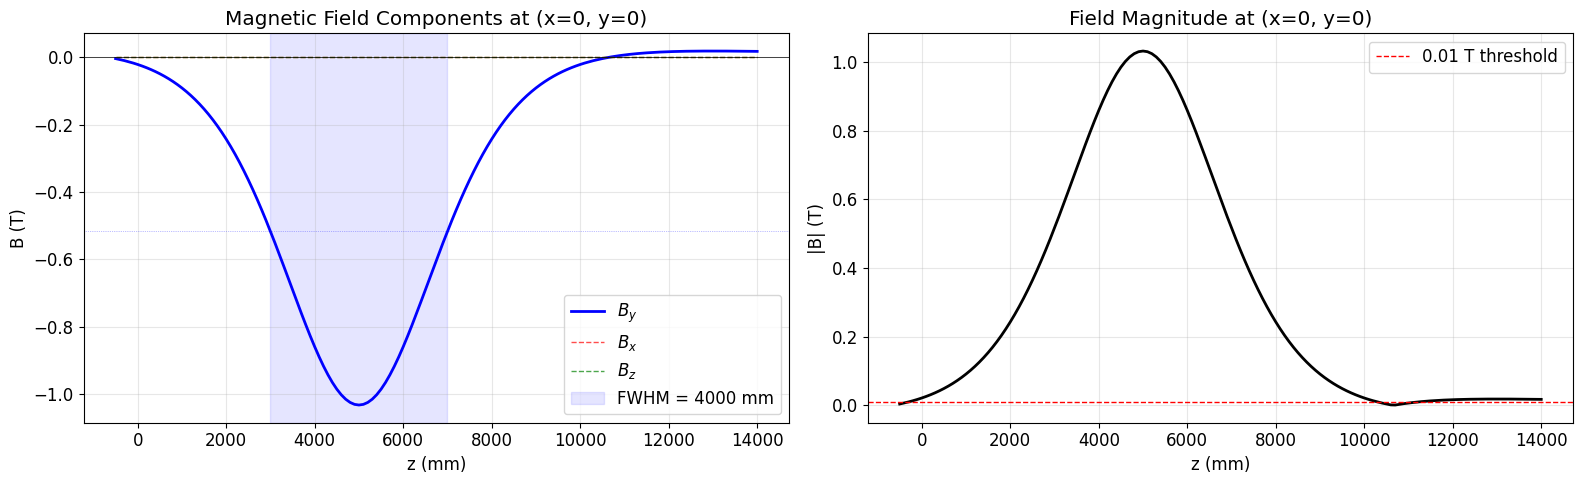

In [ ]:
# By along the beam axis (x=0, y=0)
By_z = By_3d[ix0, iy0, :]  # By(z) at origin
Bx_z = Bx_3d[ix0, iy0, :]
Bz_z = Bz_3d[ix0, iy0, :]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: By(z) profile
ax = axes[0]
ax.plot(z_grid, By_z, 'b-', linewidth=2, label='$B_y$')
ax.plot(z_grid, Bx_z, 'r--', linewidth=1, alpha=0.7, label='$B_x$')
ax.plot(z_grid, Bz_z, 'g--', linewidth=1, alpha=0.7, label='$B_z$')
ax.set_xlabel('z (mm)')
ax.set_ylabel('B (T)')
ax.set_title('Magnetic Field Components at (x=0, y=0)')
ax.legend()
ax.axhline(0, color='k', linewidth=0.5)

# Find peak and FWHM
iz_peak = np.argmin(By_z)  # Most negative = strongest
z_peak = z_grid[iz_peak]
By_peak = By_z[iz_peak]
print(f"Peak By = {By_peak:.4f} T at z = {z_peak:.0f} mm")

# FWHM: find where |By| drops to half of peak
half_max = np.abs(By_peak) / 2
above_half = np.abs(By_z) > half_max
z_above = z_grid[above_half]
z_fwhm_low, z_fwhm_high = z_above[0], z_above[-1]
fwhm = z_fwhm_high - z_fwhm_low
print(f"FWHM: {fwhm:.0f} mm (z = {z_fwhm_low:.0f} to {z_fwhm_high:.0f} mm)")

ax.axhline(By_peak/2, color='b', linewidth=0.5, linestyle=':', alpha=0.5)
ax.axvspan(z_fwhm_low, z_fwhm_high, alpha=0.1, color='blue', label=f'FWHM = {fwhm:.0f} mm')
ax.legend()

# Right: field magnitude
B_mag = np.sqrt(Bx_z**2 + By_z**2 + Bz_z**2)
ax = axes[1]
ax.plot(z_grid, B_mag, 'k-', linewidth=2)
ax.set_xlabel('z (mm)')
ax.set_ylabel('|B| (T)')
ax.set_title('Field Magnitude at (x=0, y=0)')
ax.axhline(0.01, color='r', linewidth=1, linestyle='--', label='0.01 T threshold')
ax.legend()

# Find "active" region (|B| > 0.01 T)
active = B_mag > 0.01
z_active = z_grid[active]
z_active_low, z_active_high = z_active[0], z_active[-1]
print(f"\nActive region (|B| > 0.01 T): z = {z_active_low:.0f} to {z_active_high:.0f} mm")
print(f"Active width: {z_active_high - z_active_low:.0f} mm")

plt.tight_layout()
plt.savefig('field_By_z_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 2D Field Maps — Slices Through the Detector

Visualise Bx, By, Bz as heatmaps in the (x, z) plane at y=0 and the (y, z) plane at x=0.

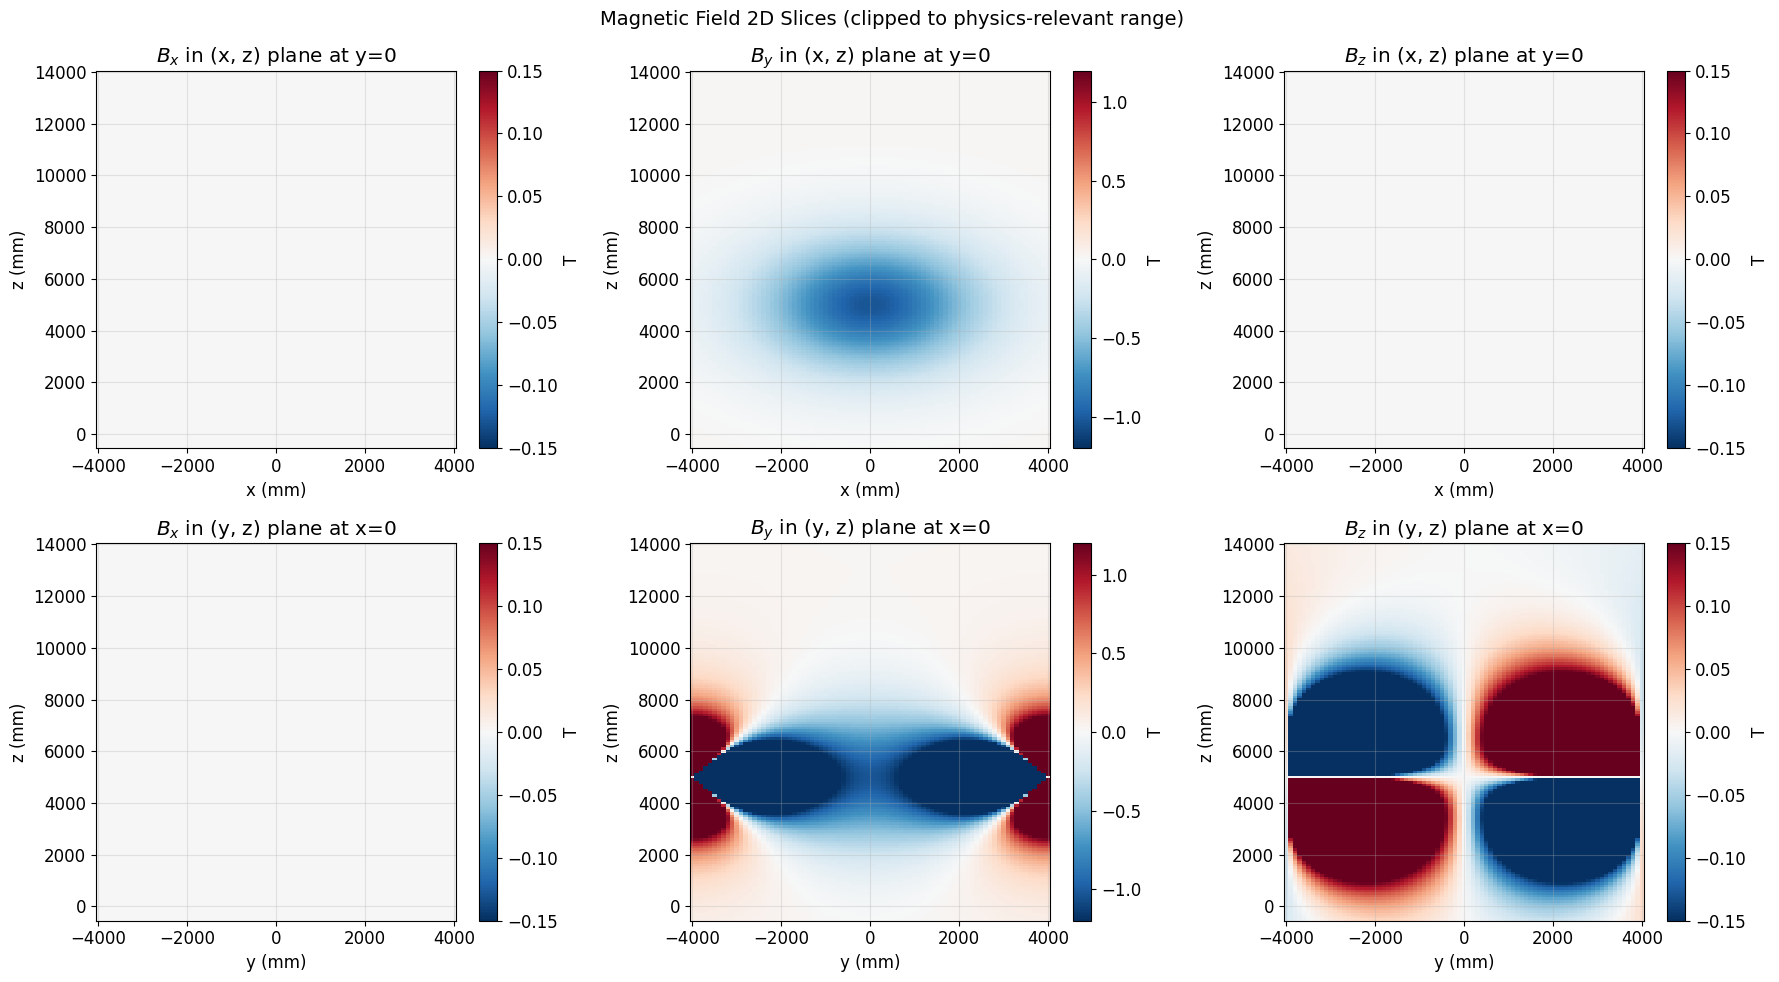

In [ ]:
# 2D slices: (x, z) at y=0 and (y, z) at x=0
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

components = [('$B_x$', Bx_3d), ('$B_y$', By_3d), ('$B_z$', Bz_3d)]
vmax_values = [0.15, 1.2, 0.15]  # Clip to physics-relevant range

for j, (label, B_3d) in enumerate(components):
    vmax = vmax_values[j]
    
    # Top row: (x, z) slice at y=0
    ax = axes[0, j]
    slice_xz = B_3d[:, iy0, :].T  # [nz, nx]
    im = ax.pcolormesh(x_grid, z_grid, slice_xz, cmap='RdBu_r', 
                       vmin=-vmax, vmax=vmax, shading='auto')
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('z (mm)')
    ax.set_title(f'{label} in (x, z) plane at y=0')
    plt.colorbar(im, ax=ax, label='T')
    
    # Bottom row: (y, z) slice at x=0
    ax = axes[1, j]
    slice_yz = B_3d[ix0, :, :].T  # [nz, ny]
    im = ax.pcolormesh(y_grid, z_grid, slice_yz, cmap='RdBu_r', 
                       vmin=-vmax, vmax=vmax, shading='auto')
    ax.set_xlabel('y (mm)')
    ax.set_ylabel('z (mm)')
    ax.set_title(f'{label} in (y, z) plane at x=0')
    plt.colorbar(im, ax=ax, label='T')

plt.suptitle('Magnetic Field 2D Slices (clipped to physics-relevant range)', fontsize=14)
plt.tight_layout()
plt.savefig('field_2d_slices.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Field Boundaries and Extreme Values

The raw data contains extreme |By| values (>1000 T) at grid edges. These are non-physical extrapolation artifacts. Let's identify the safe interpolation region.

In [ ]:
# Investigate extreme field values
B_total = np.sqrt(Bx_3d**2 + By_3d**2 + Bz_3d**2)

# Distribution of field magnitudes
thresholds = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 100.0]
print("Field magnitude statistics:")
print(f"  Min |B|: {B_total.min():.6f} T")
print(f"  Max |B|: {B_total.max():.2f} T")
print(f"  Median |B|: {np.median(B_total):.4f} T")
print()

print("Points exceeding threshold:")
for thresh in thresholds:
    n = np.sum(B_total > thresh)
    pct = 100 * n / B_total.size
    print(f"  |B| > {thresh:6.2f} T: {n:8d} points ({pct:.2f}%)")

# Where are the extreme values?
print(f"\nExtreme value analysis (|B| > 5 T):")
extreme = B_total > 5.0
if np.any(extreme):
    ix_ext, iy_ext, iz_ext = np.where(extreme)
    print(f"  x range: [{x_grid[ix_ext.min()]:.0f}, {x_grid[ix_ext.max()]:.0f}] mm")
    print(f"  y range: [{y_grid[iy_ext.min()]:.0f}, {y_grid[iy_ext.max()]:.0f}] mm")
    print(f"  z range: [{z_grid[iz_ext.min()]:.0f}, {z_grid[iz_ext.max()]:.0f}] mm")

# Check within LHCb acceptance (typical track region)
print(f"\nField within LHCb track acceptance (|x|<500, |y|<500):")
x_mask = np.abs(x_grid) <= 500
y_mask = np.abs(y_grid) <= 500
B_accept = B_total[np.ix_(x_mask, y_mask, np.ones(nz, dtype=bool))]
print(f"  Max |B|: {B_accept.max():.4f} T")
print(f"  This confirms: extreme values only at grid edges, NOT in physics region")

Field magnitude statistics:
  Min |B|: 0.000000 T
  Max |B|: 33024.07 T
  Median |B|: 0.1099 T

Points exceeding threshold:
  |B| >   0.01 T:   948009 points (98.97%)
  |B| >   0.10 T:   498131 points (52.00%)
  |B| >   0.50 T:   191207 points (19.96%)
  |B| >   1.00 T:    99887 points (10.43%)
  |B| >   2.00 T:    48940 points (5.11%)
  |B| >   5.00 T:    19700 points (2.06%)
  |B| >  10.00 T:     9988 points (1.04%)
  |B| > 100.00 T:     1068 points (0.11%)

Extreme value analysis (|B| > 5 T):
  x range: [-1400, 1400] mm
  y range: [-4000, 4000] mm
  z range: [3600, 6400] mm

Field within LHCb track acceptance (|x|<500, |y|<500):
  Max |B|: 1.1326 T
  This confirms: extreme values only at grid edges, NOT in physics region


## 5. Transverse Variation — Fringe Fields

How does the field vary across x and y at the peak z position? This determines whether the field can be treated as 1D f(z) or requires full 3D treatment.

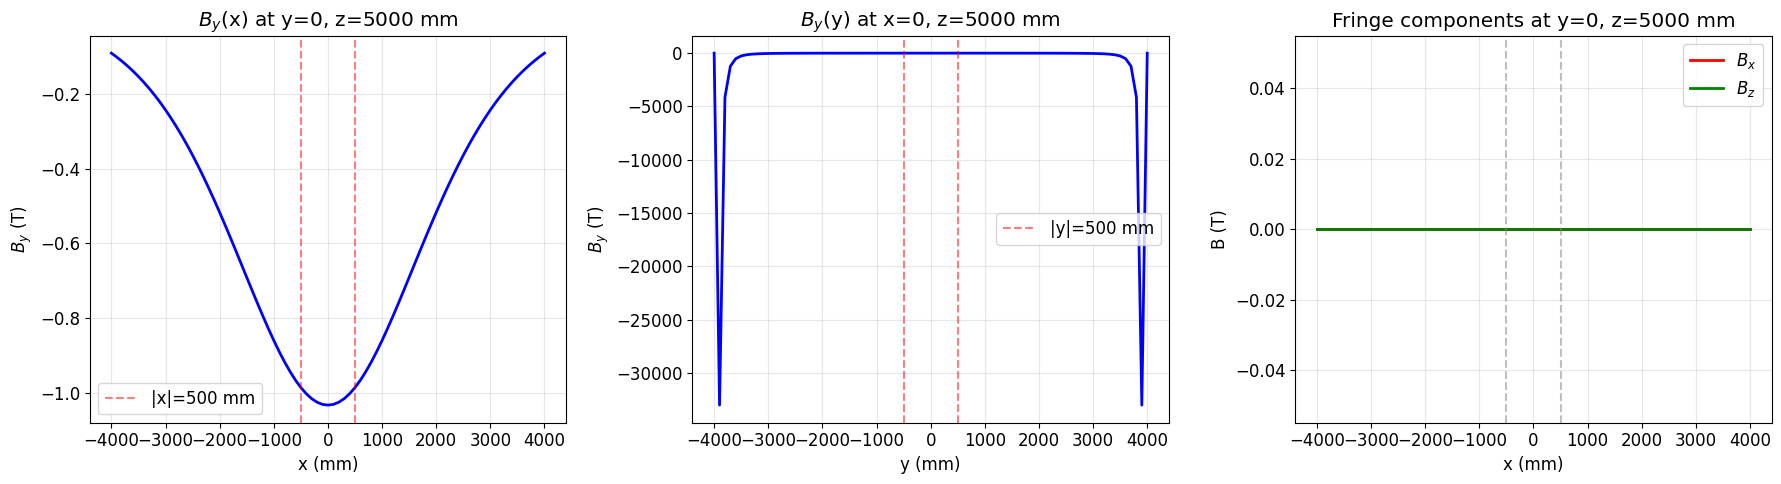

Transverse variation within |x|<500, |y|<500:
  By at center: -1.0320 T
  By range within acceptance: [-1.1326, -0.9850] T
  Relative variation: 14.31%
  => Significant transverse dependence


In [ ]:
# Transverse field variation at z = z_peak
iz_peak = np.argmin(np.abs(z_grid - z_peak))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By(x) at y=0, z=z_peak
ax = axes[0]
By_x = By_3d[:, iy0, iz_peak]
ax.plot(x_grid, By_x, 'b-', linewidth=2)
ax.set_xlabel('x (mm)')
ax.set_ylabel('$B_y$ (T)')
ax.set_title(f'$B_y$(x) at y=0, z={z_peak:.0f} mm')
ax.axvline(-500, color='r', linestyle='--', alpha=0.5, label='|x|=500 mm')
ax.axvline(500, color='r', linestyle='--', alpha=0.5)
ax.legend()

# By(y) at x=0, z=z_peak
ax = axes[1]
By_y = By_3d[ix0, :, iz_peak]
ax.plot(y_grid, By_y, 'b-', linewidth=2)
ax.set_xlabel('y (mm)')
ax.set_ylabel('$B_y$ (T)')
ax.set_title(f'$B_y$(y) at x=0, z={z_peak:.0f} mm')
ax.axvline(-500, color='r', linestyle='--', alpha=0.5, label='|y|=500 mm')
ax.axvline(500, color='r', linestyle='--', alpha=0.5)
ax.legend()

# Bx, Bz at z_peak along x (fringe components)
ax = axes[2]
Bx_x = Bx_3d[:, iy0, iz_peak]
Bz_x = Bz_3d[:, iy0, iz_peak]
ax.plot(x_grid, Bx_x, 'r-', linewidth=2, label='$B_x$')
ax.plot(x_grid, Bz_x, 'g-', linewidth=2, label='$B_z$')
ax.set_xlabel('x (mm)')
ax.set_ylabel('B (T)')
ax.set_title(f'Fringe components at y=0, z={z_peak:.0f} mm')
ax.axvline(-500, color='gray', linestyle='--', alpha=0.5)
ax.axvline(500, color='gray', linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.savefig('field_transverse_variation.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify transverse variation within acceptance
print("Transverse variation within |x|<500, |y|<500:")
x_accept = np.abs(x_grid) <= 500
y_accept = np.abs(y_grid) <= 500
By_center = By_3d[ix0, iy0, iz_peak]
By_accept = By_3d[np.ix_(x_accept, y_accept, [iz_peak])]
variation = (By_accept.max() - By_accept.min()) / np.abs(By_center) * 100
print(f"  By at center: {By_center:.4f} T")
print(f"  By range within acceptance: [{By_accept.min():.4f}, {By_accept.max():.4f}] T")
print(f"  Relative variation: {variation:.2f}%")
print(f"  => {'Negligible' if variation < 5 else 'Significant'} transverse dependence")

## 6. Gaussian Approximation Comparison

Compare the real field map with the Gaussian approximation `By(z) = B0 * exp(-0.5 * ((z - z_center) / z_width)²)` to quantify the error from using the simpler model.

Fitted Gaussian: B0=-1.0153 T, z_center=5000 mm, z_width=1757 mm
Default params:  B0=-1.0182 T, z_center=5007.0 mm, z_width=1744.0 mm


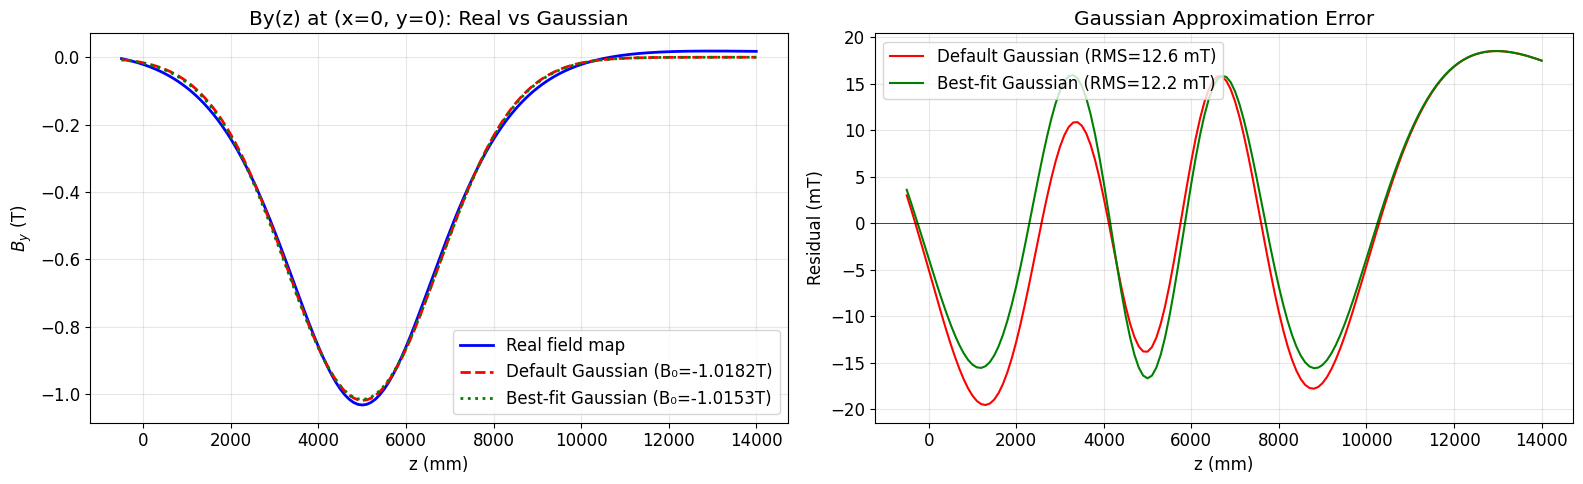


Default Gaussian approximation error:
  RMS: 12.6 mT (1.2%)
  Max: 19.5 mT
  => This is why we use the REAL field map for training data!


In [ ]:
# Compare Gaussian approximation vs real field at origin
gauss_field = GaussianFieldNumpy()
By_gauss = np.array([gauss_field(0, 0, zi)[1] for zi in z_grid])

# Also fit a Gaussian to the real data
def gaussian(z, B0, z_center, z_width):
    return B0 * np.exp(-0.5 * ((z - z_center) / z_width)**2)

# Fit to By(z) at origin
popt, pcov = curve_fit(gaussian, z_grid, By_z, p0=[-1.0, 5000, 2000])
By_fitted = gaussian(z_grid, *popt)
print(f"Fitted Gaussian: B0={popt[0]:.4f} T, z_center={popt[1]:.0f} mm, z_width={popt[2]:.0f} mm")
print(f"Default params:  B0={GaussianFieldParams.B0} T, z_center={GaussianFieldParams.z_center} mm, z_width={GaussianFieldParams.z_width} mm")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: overlay
ax = axes[0]
ax.plot(z_grid, By_z, 'b-', linewidth=2, label='Real field map')
ax.plot(z_grid, By_gauss, 'r--', linewidth=2, label=f'Default Gaussian (B₀={GaussianFieldParams.B0}T)')
ax.plot(z_grid, By_fitted, 'g:', linewidth=2, label=f'Best-fit Gaussian (B₀={popt[0]:.4f}T)')
ax.set_xlabel('z (mm)')
ax.set_ylabel('$B_y$ (T)')
ax.set_title('By(z) at (x=0, y=0): Real vs Gaussian')
ax.legend()

# Right: residuals
ax = axes[1]
residual_default = By_z - By_gauss
residual_fitted = By_z - By_fitted
ax.plot(z_grid, residual_default * 1000, 'r-', linewidth=1.5, label=f'Default Gaussian (RMS={np.std(residual_default)*1000:.1f} mT)')
ax.plot(z_grid, residual_fitted * 1000, 'g-', linewidth=1.5, label=f'Best-fit Gaussian (RMS={np.std(residual_fitted)*1000:.1f} mT)')
ax.set_xlabel('z (mm)')
ax.set_ylabel('Residual (mT)')
ax.set_title('Gaussian Approximation Error')
ax.legend()
ax.axhline(0, color='k', linewidth=0.5)

plt.tight_layout()
plt.savefig('field_gaussian_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Error statistics
rms_default = np.sqrt(np.mean(residual_default**2))
max_default = np.max(np.abs(residual_default))
rel_error = rms_default / np.max(np.abs(By_z)) * 100
print(f"\nDefault Gaussian approximation error:")
print(f"  RMS: {rms_default*1000:.1f} mT ({rel_error:.1f}%)")
print(f"  Max: {max_default*1000:.1f} mT")
print(f"  => This is why we use the REAL field map for training data!")

## 7. Recommended z-Range for Training Data

Based on the field analysis, determine the optimal z_start and z_end for training data generation. We want to cover the full field region where tracks experience significant bending, plus some margin.

TRAINING DATA z-RANGE RECOMMENDATION

Field integral analysis:
  Total ∫|By|dz = 4543.5 T·mm
  1% of integral at z = 900 mm
  99% of integral at z = 11400 mm
  Central 98%: z = 900 to 11400 mm


/tmp/ipykernel_2757487/113179119.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_full = np.trapz(By_abs, z_grid)


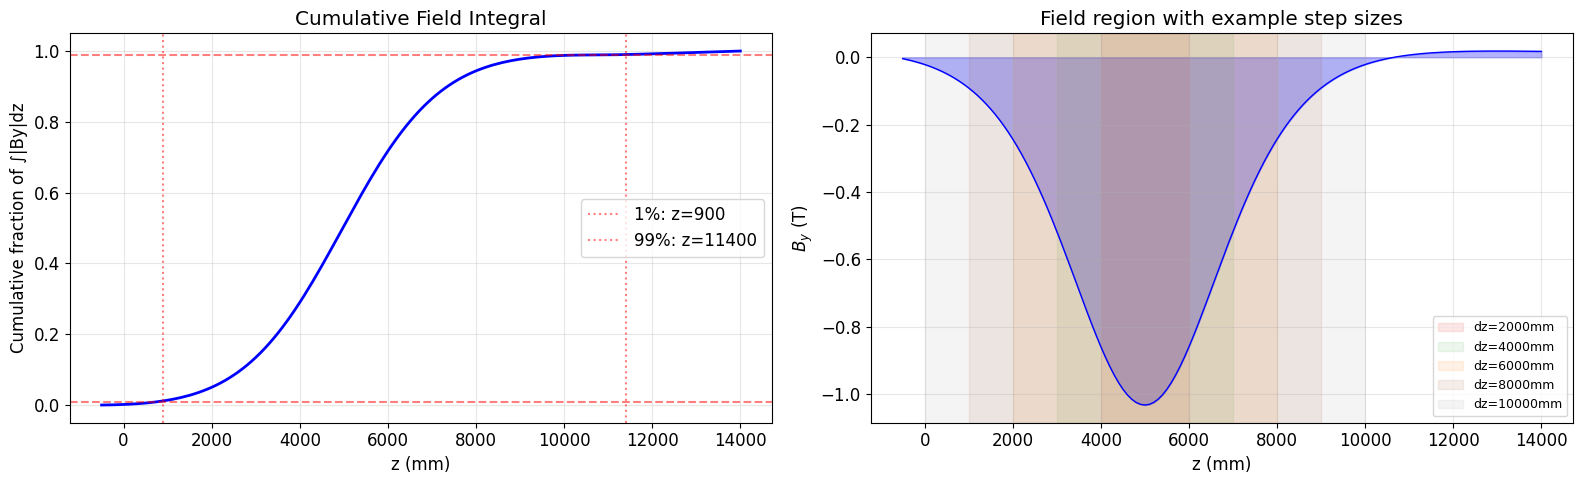


RECOMMENDATIONS FOR DATA GENERATION
  z_start range: [-500, 11400] mm (sample uniformly)
  z_end range: [900, 14000] mm (sample uniformly)
  Constraint: z_end > z_start (forward propagation)
  dz range: [100, 14500] mm (variable!)
  x range: [-300, 300] mm (well within grid acceptance)
  y range: [-250, 250] mm (well within grid acceptance)
  tx range: [-0.3, 0.3]
  ty range: [-0.25, 0.25]
  p range: [1, 100] GeV (log-uniform)
  Field: twodip.rtf (interpolated, NOT Gaussian)
  RK4 step: 5 mm
  Polarity: -1 (MagDown, matches fitted B0)


In [ ]:
# Determine z-range recommendation based on field analysis
print("=" * 70)
print("TRAINING DATA z-RANGE RECOMMENDATION")
print("=" * 70)

# Integrated field strength (∫|By|dz) as function of z limits
By_abs = np.abs(By_z)
integral_full = np.trapz(By_abs, z_grid)

# Find where cumulative integral reaches 1% and 99%
cumulative = np.cumsum(By_abs * (z_grid[1] - z_grid[0]))
cumulative /= cumulative[-1]

z_1pct = z_grid[np.searchsorted(cumulative, 0.01)]
z_99pct = z_grid[np.searchsorted(cumulative, 0.99)]

print(f"\nField integral analysis:")
print(f"  Total ∫|By|dz = {integral_full:.1f} T·mm")
print(f"  1% of integral at z = {z_1pct:.0f} mm")
print(f"  99% of integral at z = {z_99pct:.0f} mm")
print(f"  Central 98%: z = {z_1pct:.0f} to {z_99pct:.0f} mm")

# Plot cumulative integral
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(z_grid, cumulative, 'b-', linewidth=2)
ax.axhline(0.01, color='r', linestyle='--', alpha=0.5)
ax.axhline(0.99, color='r', linestyle='--', alpha=0.5)
ax.axvline(z_1pct, color='r', linestyle=':', alpha=0.5, label=f'1%: z={z_1pct:.0f}')
ax.axvline(z_99pct, color='r', linestyle=':', alpha=0.5, label=f'99%: z={z_99pct:.0f}')
ax.set_xlabel('z (mm)')
ax.set_ylabel('Cumulative fraction of ∫|By|dz')
ax.set_title('Cumulative Field Integral')
ax.legend()

# Recommended range — round to nice numbers with margin
z_start_rec = 0    # Include pre-magnet region for trajectory context
z_end_rec = 14000  # Full grid coverage, field negligible beyond ~10000mm

# Show various dz options
ax = axes[1]
By_z_plot = By_z.copy()
ax.fill_between(z_grid, By_z_plot, alpha=0.3, color='blue')
ax.plot(z_grid, By_z_plot, 'b-', linewidth=1)

# Show example track z ranges for variable dz training
dz_examples = [2000, 4000, 6000, 8000, 10000]
colors = plt.cm.Set1(np.linspace(0, 1, len(dz_examples)))
for dz, c in zip(dz_examples, colors):
    z_s = z_peak - dz/2
    z_e = z_peak + dz/2
    ax.axvspan(z_s, z_e, alpha=0.1, color=c, label=f'dz={dz}mm')
    
ax.set_xlabel('z (mm)')
ax.set_ylabel('$B_y$ (T)')
ax.set_title('Field region with example step sizes')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('field_z_range_recommendation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final recommendations
print(f"\n{'='*70}")
print("RECOMMENDATIONS FOR DATA GENERATION")
print(f"{'='*70}")
print(f"  z_start range: [{z_grid[0]:.0f}, {z_99pct:.0f}] mm (sample uniformly)")
print(f"  z_end range: [{z_1pct:.0f}, {z_grid[-1]:.0f}] mm (sample uniformly)")
print(f"  Constraint: z_end > z_start (forward propagation)")
print(f"  dz range: [100, {z_grid[-1] - z_grid[0]:.0f}] mm (variable!)")
print(f"  x range: [-300, 300] mm (well within grid acceptance)")
print(f"  y range: [-250, 250] mm (well within grid acceptance)")
print(f"  tx range: [-0.3, 0.3]")
print(f"  ty range: [-0.25, 0.25]")
print(f"  p range: [1, 100] GeV (log-uniform)")
print(f"  Field: twodip.rtf (interpolated, NOT Gaussian)")
print(f"  RK4 step: 5 mm")
print(f"  Polarity: -1 (MagDown, matches fitted B0)")
print(f"{'='*70}")

## 8. Summary Statistics

Concise table of all field characteristics for the `FIELD_ANALYSIS.md` document.

In [ ]:
# Summary table
print("=" * 70)
print("FIELD MAP SUMMARY")
print("=" * 70)
print(f"""
Grid Specification:
  File: twodip.rtf
  Grid: {nx} × {ny} × {nz} = {nx*ny*nz:,} points
  Spacing: 100 mm (x, y, z)
  x range: [{x_grid[0]:.0f}, {x_grid[-1]:.0f}] mm
  y range: [{y_grid[0]:.0f}, {y_grid[-1]:.0f}] mm
  z range: [{z_grid[0]:.0f}, {z_grid[-1]:.0f}] mm

Field Characteristics (at x=0, y=0):
  Peak By: {By_peak:.4f} T at z = {z_peak:.0f} mm
  FWHM: {fwhm:.0f} mm (z = {z_fwhm_low:.0f} to {z_fwhm_high:.0f} mm)
  Active region (|B|>0.01T): z = {z_active_low:.0f} to {z_active_high:.0f} mm
  Field integral (∫|By|dz, central 98%): z = {z_1pct:.0f} to {z_99pct:.0f} mm

Gaussian Approximation:
  Fitted B0 = {popt[0]:.4f} T, z_center = {popt[1]:.0f} mm, z_width = {popt[2]:.0f} mm
  RMS error: {rms_default*1000:.1f} mT ({rel_error:.1f}%)
  Max error: {max_default*1000:.1f} mT
  Conclusion: NOT suitable for high-precision training data

Extreme Values:
  Max |B| in full grid: {B_total.max():.1f} T (grid-edge artifacts)
  Max |B| within |x,y|<500mm: {B_accept.max():.4f} T (physically correct)
  Safe region: |x| < 500 mm, |y| < 500 mm
""")
print("=" * 70)

FIELD MAP SUMMARY

Grid Specification:
  File: twodip.rtf
  Grid: 81 × 81 × 146 = 957,906 points
  Spacing: 100 mm (x, y, z)
  x range: [-4000, 4000] mm
  y range: [-4000, 4000] mm
  z range: [-500, 14000] mm

Field Characteristics (at x=0, y=0):
  Peak By: -1.0320 T at z = 5000 mm
  FWHM: 4000 mm (z = 3000 to 7000 mm)
  Active region (|B|>0.01T): z = -300 to 14000 mm
  Field integral (∫|By|dz, central 98%): z = 900 to 11400 mm

Gaussian Approximation:
  Fitted B0 = -1.0153 T, z_center = 5000 mm, z_width = 1757 mm
  RMS error: 12.6 mT (1.2%)
  Max error: 19.5 mT
  Conclusion: NOT suitable for high-precision training data

Extreme Values:
  Max |B| in full grid: 33024.1 T (grid-edge artifacts)
  Max |B| within |x,y|<500mm: 1.1326 T (physically correct)
  Safe region: |x| < 500 mm, |y| < 500 mm

